Charge par technicien
Combien d'opérations assignées à chaque technicien ?

In [ ]:
#imports & chargements
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

tech = pd.read_csv('final_tables/technicians_final.csv')
woo  = pd.read_csv('final_tables/woo_final.csv')

print('Technicians :', tech.shape)
print('Opérations  :', woo.shape)

Technicians : (7, 18)
Opérations  : (1096, 28)


In [12]:
#Jointure
woo_tech = woo.merge(
    tech[['pk_technician_id', 'technician_full_name', 'skill_description']],
    left_on='fk_assigned_technician_id',
    right_on='pk_technician_id',
    how='left'
)

woo_tech[['pk_woo_id', 'status', 'operation_type', 'fk_assigned_technician_id', 'technician_full_name']].head(10)

,pk_woo_id,status,operation_type,fk_assigned_technician_id,technician_full_name
0,132,To do,Preventive,NaN,NaN
1,133,To do,Preventive,NaN,NaN
2,134,To do,Preventive,NaN,NaN
3,135,To do,Preventive,NaN,NaN
4,136,To do,Preventive,NaN,NaN
5,137,To do,Corrective,NaN,NaN
6,138,To do,Corrective,NaN,NaN
7,139,To do,Corrective,NaN,NaN
8,140,To do,Corrective,NaN,NaN
9,141,To do,Corrective,NaN,NaN


In [13]:
total         = len(woo)
assignees     = woo['fk_assigned_technician_id'].notna().sum()
non_assignees = total - assignees

print(f'Total opérations         : {total}')
print(f'Opérations assignées     : {assignees}  ({assignees/total*100:.1f}%)')
print(f'Opérations NON assignées : {non_assignees}  ({non_assignees/total*100:.1f}%)')

Total opérations         : 1096
Opérations assignées     : 0  (0.0%)
Opérations NON assignées : 1096  (100.0%)


In [14]:
charge = (
    woo_tech[woo_tech['technician_full_name'].notna()]
    .groupby('technician_full_name')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='nb_operations')
)

display(charge)

,technician_full_name,nb_operations


Nombre total d'opérations assignées par technicien

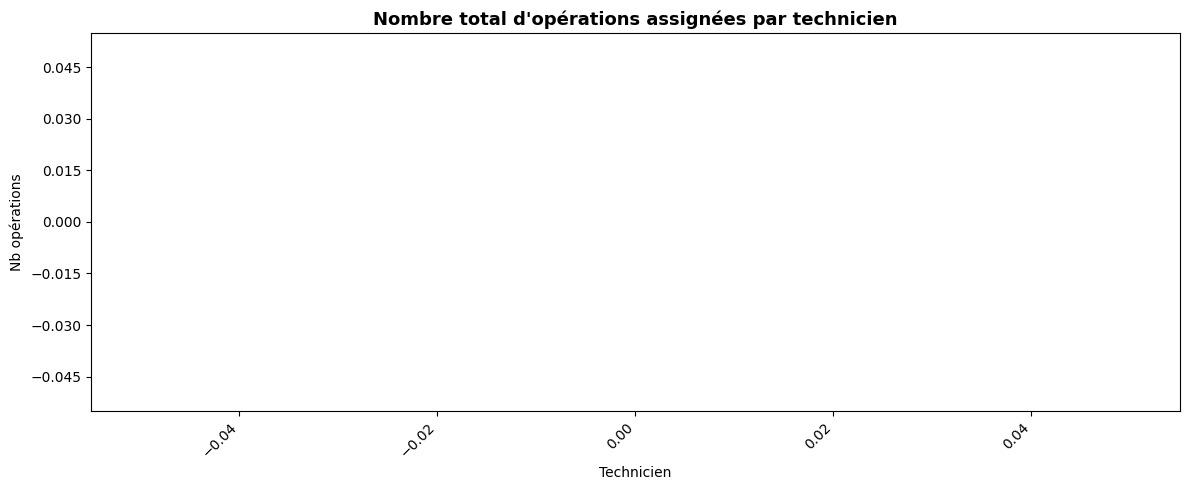

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(charge['technician_full_name'], charge['nb_operations'], color='steelblue', edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

ax.set_title("Nombre total d'opérations assignées par technicien", fontsize=13, fontweight='bold')
ax.set_xlabel('Technicien')
ax.set_ylabel('Nb opérations')
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

pour l''instant aucune operation n''ai assigné à un technicien ( et c''est normal a ce stade )

 Répartition des types d'opérations
 Breakdown vs Corrective vs Preventive → graphiques

In [ ]:
#vérification des types d'opérations
print(woo['operation_type'].value_counts())

operation_type
Corrective    876
Preventive    220
Name: count, dtype: int64


nombre et type d'operation

In [18]:
repartition = (
    woo['operation_type']
    .value_counts()
    .reset_index()
)
repartition.columns = ['type_operation', 'nb_operations']
repartition['%'] = (repartition['nb_operations'] / repartition['nb_operations'].sum() * 100).round(1)

display(repartition)

,type_operation,nb_operations,%
0,Corrective,876,79.9
1,Preventive,220,20.1


Répartition de types d'operationss

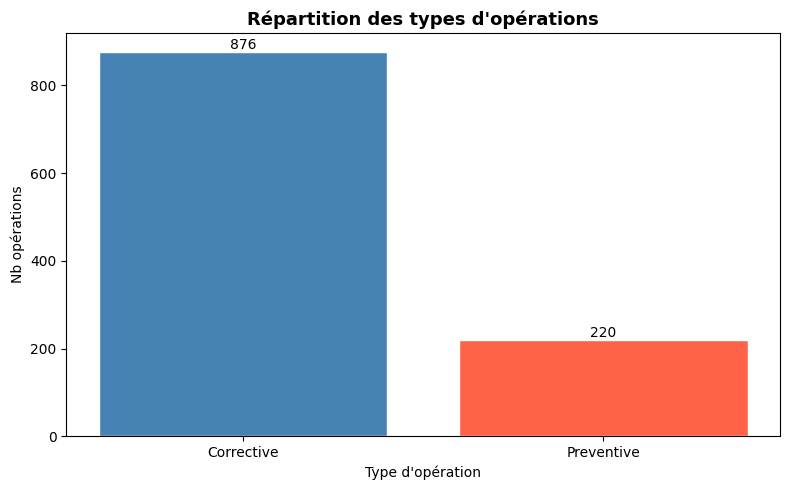

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(repartition['type_operation'], repartition['nb_operations'], color=['steelblue', 'tomato', 'seagreen'], edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

ax.set_title("Répartition des types d'opérations", fontsize=13, fontweight='bold')
ax.set_xlabel("Type d'opération")
ax.set_ylabel("Nb opérations")
plt.tight_layout()
plt.show()

Répartition  par type et sous-type d'operation

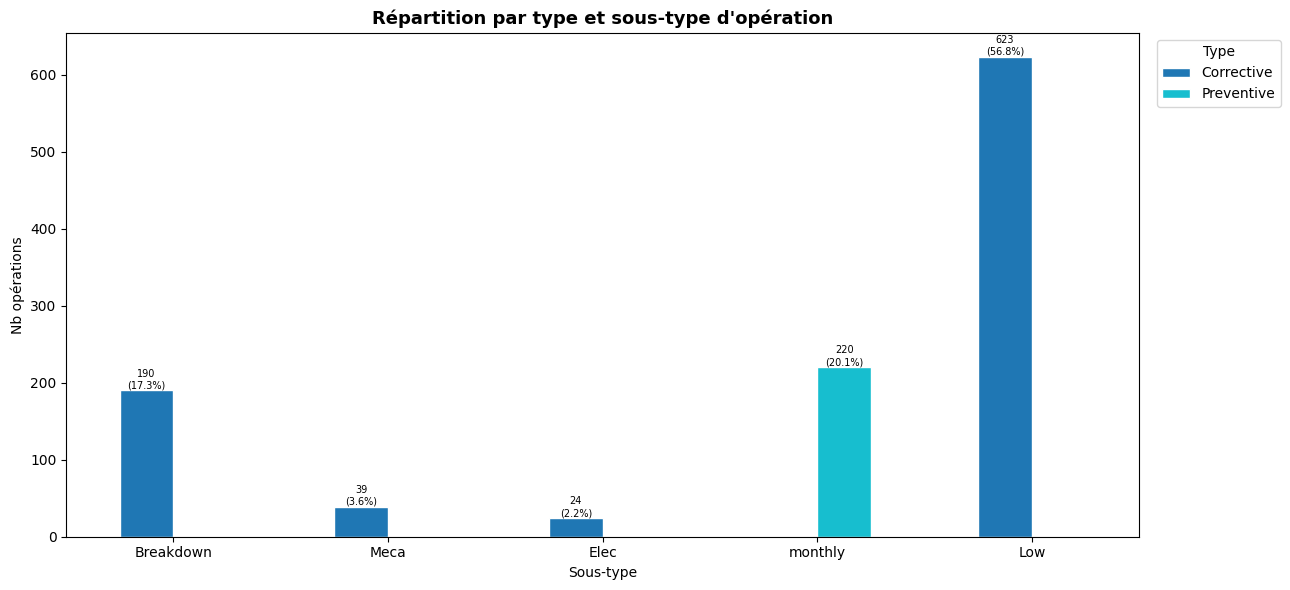

In [25]:
ordre = ['Breakdown', 'Meca', 'Elec', 'monthly', 'Low']

sous_type = (
    woo.groupby(['operation_type', 'operation_subtype'])
    .size()
    .reset_index(name='nb_operations')
)

sous_type_pivot = sous_type.pivot(index='operation_subtype', columns='operation_type', values='nb_operations').fillna(0)

ordre_filtre = [x for x in ordre if x in sous_type_pivot.index]
sous_type_pivot = sous_type_pivot.reindex(ordre_filtre)

total_global = sous_type_pivot.values.sum()

ax = sous_type_pivot.plot(kind='bar', figsize=(13, 6), colormap='tab10', edgecolor='white')

for container in ax.containers:
    for bar in container:
        val = bar.get_height()
        if val > 0:
            pct = val / total_global * 100
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{int(val)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=7)

plt.title("Répartition par type et sous-type d'opération", fontsize=13, fontweight='bold')
plt.xlabel("Sous-type")
plt.ylabel("Nb opérations")
plt.xticks(rotation=0)
plt.legend(title='Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

 Assets les plus critiques
 Quels assets ont le plus d'interventions ?

In [26]:
print(woo[['asset_description', 'asset_criticality', 'asset_status']].value_counts().head(20))

asset_description      asset_criticality  asset_status
Asset Description 2    Adequate           In service      10
Asset Description 92   Bad                In service      10
Asset Description 93   Good               In service      10
Asset Description 94   Good               In service      10
Asset Description 95   Good               In service      10
Asset Description 96   Good               In service      10
Asset Description 97   Good               In service      10
Asset Description 98   Good               In service      10
Asset Description 99   Good               In service      10
Asset Description 100  Bad                In service      10
Asset Description 101  Adequate           In service      10
Asset Description 102  Bad                In service      10
Asset Description 103  Adequate           In service      10
Asset Description 104  Bad                In service      10
Asset Description 106  Good               In service      10
Asset Description 107  Good   

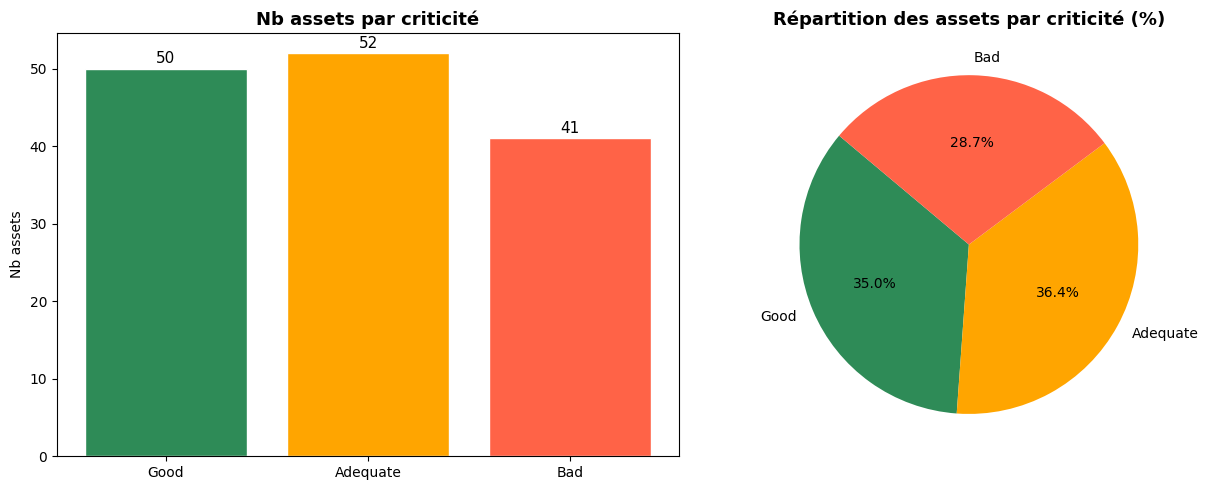

In [40]:
ordre_crit = ['Good', 'Adequate', 'Bad']

assets_uniques = (
    woo[['asset_description', 'asset_criticality']]
    .drop_duplicates()['asset_criticality']
    .value_counts()
    .reset_index()
)
assets_uniques.columns = ['criticite', 'nb_assets']
assets_uniques['criticite'] = pd.Categorical(assets_uniques['criticite'], categories=ordre_crit, ordered=True)
assets_uniques = assets_uniques.sort_values('criticite')

colors_crit = {'Good': 'seagreen', 'Adequate': 'orange', 'Bad': 'tomato'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(assets_uniques['criticite'], assets_uniques['nb_assets'],
                   color=[colors_crit.get(c, 'grey') for c in assets_uniques['criticite']],
                   edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)
axes[0].set_title('Nb assets par criticité', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nb assets')

# Pie chart
axes[1].pie(assets_uniques['nb_assets'],
            labels=assets_uniques['criticite'],
            autopct='%1.1f%%',
            colors=[colors_crit.get(c, 'grey') for c in assets_uniques['criticite']],
            startangle=140)
axes[1].set_title('Répartition des assets par criticité (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

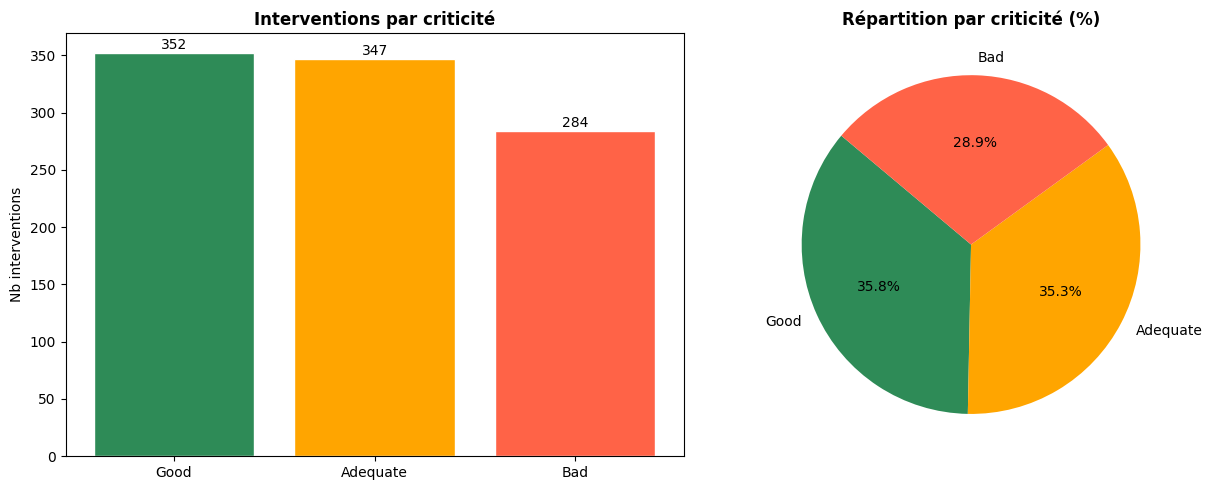

In [39]:
ordre_crit = ['Good', 'Adequate', 'Bad']

crit = (
    woo.groupby('asset_criticality')
    .size()
    .reset_index(name='nb_interventions')
)
crit['asset_criticality'] = pd.Categorical(crit['asset_criticality'], categories=ordre_crit, ordered=True)
crit = crit.sort_values('asset_criticality')

colors = {'Good': 'seagreen', 'Adequate': 'orange', 'Bad': 'tomato'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar
axes[0].bar(crit['asset_criticality'], crit['nb_interventions'],
            color=[colors.get(c, 'grey') for c in crit['asset_criticality']], edgecolor='white')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Interventions par criticité', fontweight='bold')
axes[0].set_ylabel('Nb interventions')

# Pie
axes[1].pie(crit['nb_interventions'],
            labels=crit['asset_criticality'],
            autopct='%1.1f%%',
            colors=[colors.get(c, 'grey') for c in crit['asset_criticality']],
            startangle=140)
axes[1].set_title('Répartition par criticité (%)', fontweight='bold')

plt.tight_layout()
plt.show()

 Analyse des délais
Les dates de fin sont-elles respectables ?

In [32]:
print(woo[['order_basic_start_date', 'order_basic_end_date', 'operation_scheduled_start', 'operation_scheduled_end', 'status']].head(10))

  order_basic_start_date order_basic_end_date  operation_scheduled_start  \
0              4/11/2024            8/11/2024                        NaN   
1              4/11/2024            8/11/2024                        NaN   
2              4/11/2024            8/11/2024                        NaN   
3              4/11/2024            8/11/2024                        NaN   
4              4/11/2024            8/11/2024                        NaN   
5                    NaN                  NaN                        NaN   
6                    NaN                  NaN                        NaN   
7                    NaN                  NaN                        NaN   
8                    NaN                  NaN                        NaN   
9                    NaN                  NaN                        NaN   

   operation_scheduled_end status  
0                      NaN  To do  
1                      NaN  To do  
2                      NaN  To do  
3                  

In [33]:
print("order_basic_start_date   :", woo['order_basic_start_date'].notna().sum(), '/', len(woo))
print("order_basic_end_date     :", woo['order_basic_end_date'].notna().sum(), '/', len(woo))
print("operation_scheduled_start:", woo['operation_scheduled_start'].notna().sum(), '/', len(woo))
print("operation_scheduled_end  :", woo['operation_scheduled_end'].notna().sum(), '/', len(woo))

order_basic_start_date   : 318 / 1096
order_basic_end_date     : 318 / 1096
operation_scheduled_start: 0 / 1096
operation_scheduled_end  : 0 / 1096


In [41]:
# Distribution générale de operation_order
dist_order = (
    woo['operation_order']
    .value_counts()
    .sort_index()
    .reset_index()
)
dist_order.columns = ['operation_order', 'nb_operations']

print(dist_order)

   operation_order  nb_operations
0                1            177
1                2            177
2                3            165
3                4            152
4                5            152
5                6            108
6                7            108
7                8             19
8                9             19
9               10             19


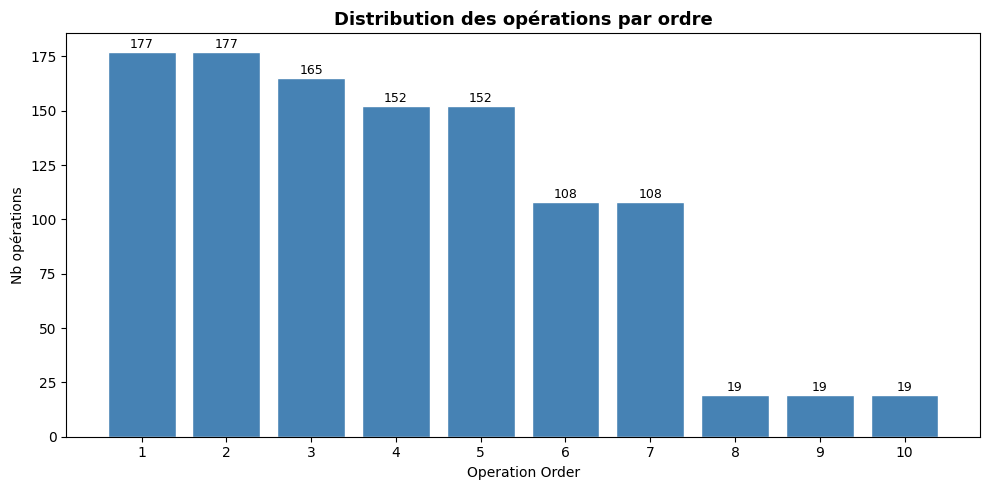

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(dist_order['operation_order'], dist_order['nb_operations'], color='steelblue', edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

ax.set_title("Distribution des opérations par ordre", fontsize=13, fontweight='bold')
ax.set_xlabel("Operation Order")
ax.set_ylabel("Nb opérations")
ax.set_xticks(dist_order['operation_order'])
plt.tight_layout()
plt.show()

In [45]:
# Extraire le work order (sans le numéro final)
woo['work_order'] = woo['operation_key'].str.rsplit('-', n=1).str[0]

# Nb d'opérations par work order
wo_count = (
    woo.groupby('work_order')
    .size()
    .reset_index(name='nb_operations')
    .sort_values('nb_operations', ascending=False)
)

display(wo_count)

,work_order,nb_operations
2,Corrective-Low,623
4,Preventive-monthly,220
0,Corrective-Breakdown,190
3,Corrective-Meca,39
1,Corrective-Elec,24


In [46]:
print(woo['required_skill_desc'].value_counts())

required_skill_desc
Electrician, Mecanician, Inspector Junior, Inspector Senior    623
Inspector Junior, Inspector Senior                             220
Electrician, Mecanician, Inspector Senior                      190
Mecanician                                                      39
Electrician                                                     24
Name: count, dtype: int64


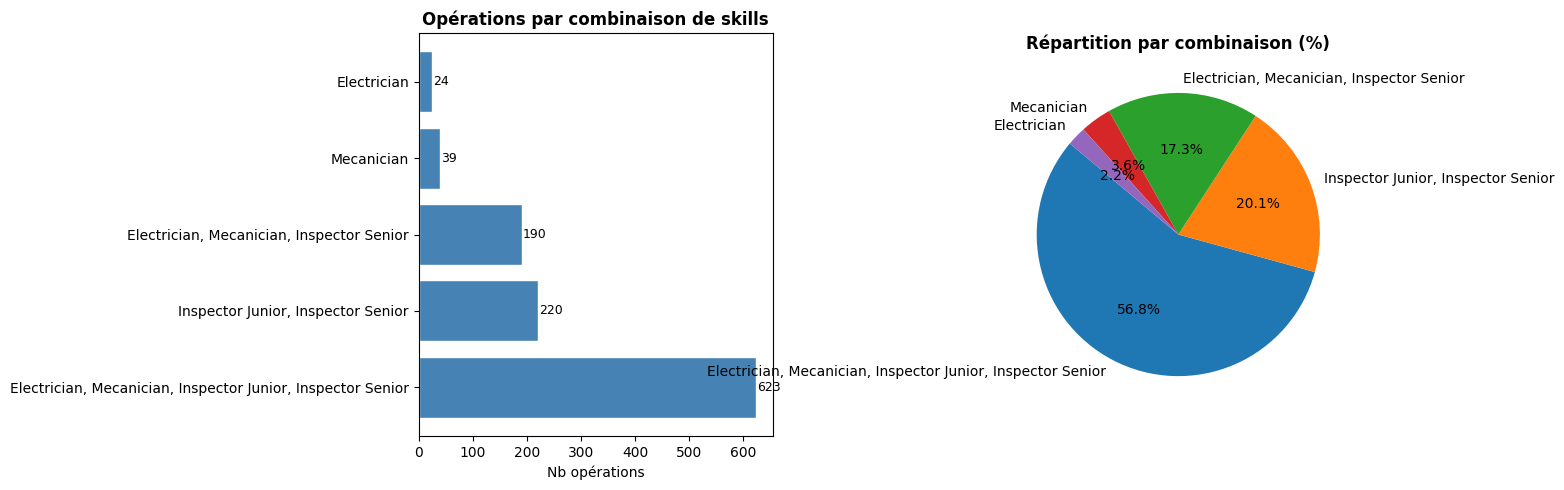

In [47]:
combo = woo['required_skill_desc'].value_counts().reset_index()
combo.columns = ['skill_combo', 'nb_operations']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar
bars = axes[0].barh(combo['skill_combo'], combo['nb_operations'], color='steelblue', edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())), va='center', fontsize=9)
axes[0].set_title('Opérations par combinaison de skills', fontweight='bold')
axes[0].set_xlabel('Nb opérations')

# Pie
axes[1].pie(combo['nb_operations'],
            labels=combo['skill_combo'],
            autopct='%1.1f%%',
            startangle=140)
axes[1].set_title('Répartition par combinaison (%)', fontweight='bold')

plt.tight_layout()
plt.show()

In [50]:
# Pour chaque opération, on vérifie si le skill du technicien est dans required_skill_desc
rows = []
for _, t in tech.iterrows():
    for _, op in woo[['required_skill_desc', 'operation_type', 'operation_subtype']].drop_duplicates().iterrows():
        if pd.notna(op['required_skill_desc']) and t['skill_description'] in op['required_skill_desc']:
            rows.append({
                'technicien': t['technician_full_name'],
                'skill': t['skill_description'],
                'required_skill': op['required_skill_desc'],
                'operation_type': op['operation_type'],
                'operation_subtype': op['operation_subtype']
            })

matching = pd.DataFrame(rows)
display(matching)

,technicien,skill,required_skill,operation_type,operation_subtype
0,Luc Dupuis,Mecanician,"Electrician, Mecanician, Inspector Senior",Corrective,Breakdown
1,Luc Dupuis,Mecanician,"Electrician, Mecanician, Inspector Junior, Ins...",Corrective,Low
2,Luc Dupuis,Mecanician,Mecanician,Corrective,Meca
3,André Philippe,Inspector Junior,"Inspector Junior, Inspector Senior",Preventive,monthly
4,André Philippe,Inspector Junior,"Electrician, Mecanician, Inspector Junior, Ins...",Corrective,Low
5,Charles Renault,Inspector Senior,"Inspector Junior, Inspector Senior",Preventive,monthly
6,Charles Renault,Inspector Senior,"Electrician, Mecanician, Inspector Senior",Corrective,Breakdown
7,Charles Renault,Inspector Senior,"Electrician, Mecanician, Inspector Junior, Ins...",Corrective,Low
8,Jacques Lefèvre,Electrician,"Electrician, Mecanician, Inspector Senior",Corrective,Breakdown
9,Jacques Lefèvre,Electrician,"Electrician, Mecanician, Inspector Junior, Ins...",Corrective,Low


In [51]:
couverture = []
for _, t in tech.iterrows():
    nb = woo['required_skill_desc'].dropna().apply(lambda x: t['skill_description'] in x).sum()
    couverture.append({'technicien': t['technician_full_name'], 'skill': t['skill_description'], 'nb_operations_couvrables': nb})

couverture_df = pd.DataFrame(couverture).sort_values('nb_operations_couvrables', ascending=False)
display(couverture_df)

,technicien,skill,nb_operations_couvrables
2,Charles Renault,Inspector Senior,1033
6,Victor Caron,Inspector Senior,1033
0,Luc Dupuis,Mecanician,852
1,André Philippe,Inspector Junior,843
4,Jean Durand,Inspector Junior,843
5,Mathieu Gérard,Inspector Junior,843
3,Jacques Lefèvre,Electrician,837


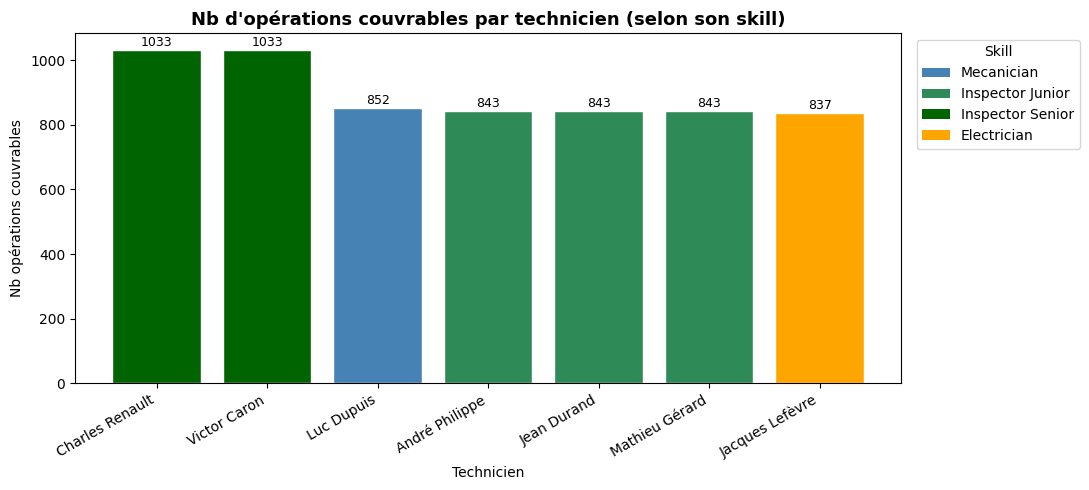

In [52]:
colors_skill = {
    'Mecanician': 'steelblue',
    'Inspector Junior': 'seagreen',
    'Inspector Senior': 'darkgreen',
    'Electrician': 'orange'
}

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(couverture_df['technicien'], couverture_df['nb_operations_couvrables'],
              color=[colors_skill.get(s, 'grey') for s in couverture_df['skill']],
              edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

ax.set_title("Nb d'opérations couvrables par technicien (selon son skill)", fontsize=13, fontweight='bold')
ax.set_xlabel('Technicien')
ax.set_ylabel("Nb opérations couvrables")
plt.xticks(rotation=30, ha='right')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_skill.items()]
ax.legend(handles=legend_elements, title='Skill', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [55]:
# On mappe les villes des techniciens vers les régions
region_map = {'Bruxelles': 'Brussels', 'Gent': 'Flanders', 'Liège': 'Wallonia'}
tech['region'] = tech['address_city'].map(region_map)

display(tech[['technician_full_name', 'skill_description', 'address_city', 'region']])

,technician_full_name,skill_description,address_city,region
0,Luc Dupuis,Mecanician,Bruxelles,Brussels
1,André Philippe,Inspector Junior,Bruxelles,Brussels
2,Charles Renault,Inspector Senior,Bruxelles,Brussels
3,Jacques Lefèvre,Electrician,Gent,Flanders
4,Jean Durand,Inspector Junior,Gent,Flanders
5,Mathieu Gérard,Inspector Junior,Liège,Wallonia
6,Victor Caron,Inspector Senior,Liège,Wallonia


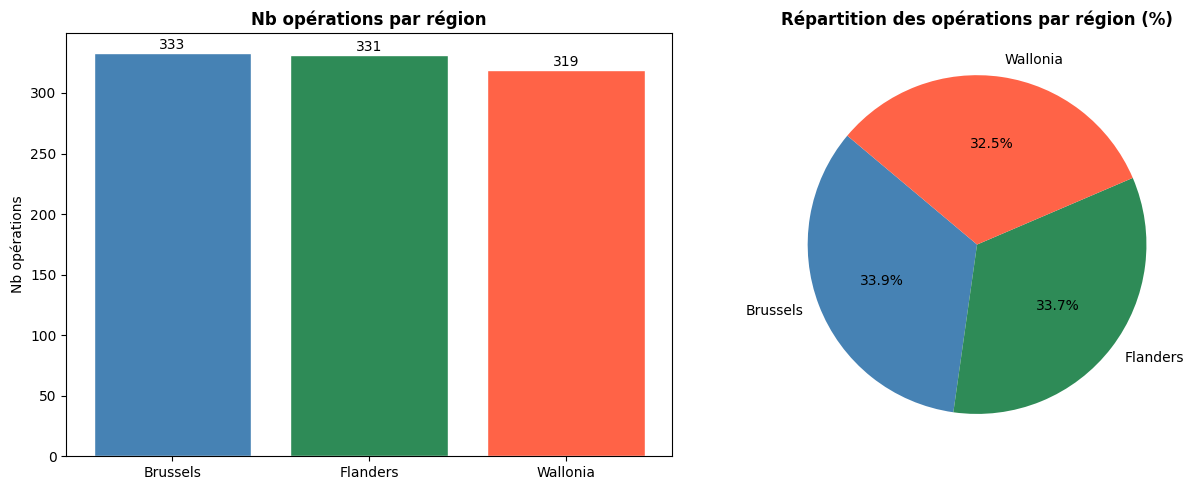

In [56]:
ops_region = woo['asset_address_region'].value_counts().reset_index()
ops_region.columns = ['region', 'nb_operations']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_region = {'Brussels': 'steelblue', 'Flanders': 'seagreen', 'Wallonia': 'tomato'}

bars = axes[0].bar(ops_region['region'], ops_region['nb_operations'],
                   color=[colors_region.get(r, 'grey') for r in ops_region['region']],
                   edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Nb opérations par région', fontweight='bold')
axes[0].set_ylabel('Nb opérations')

axes[1].pie(ops_region['nb_operations'],
            labels=ops_region['region'],
            autopct='%1.1f%%',
            colors=[colors_region.get(r, 'grey') for r in ops_region['region']],
            startangle=140)
axes[1].set_title('Répartition des opérations par région (%)', fontweight='bold')

plt.tight_layout()
plt.show()

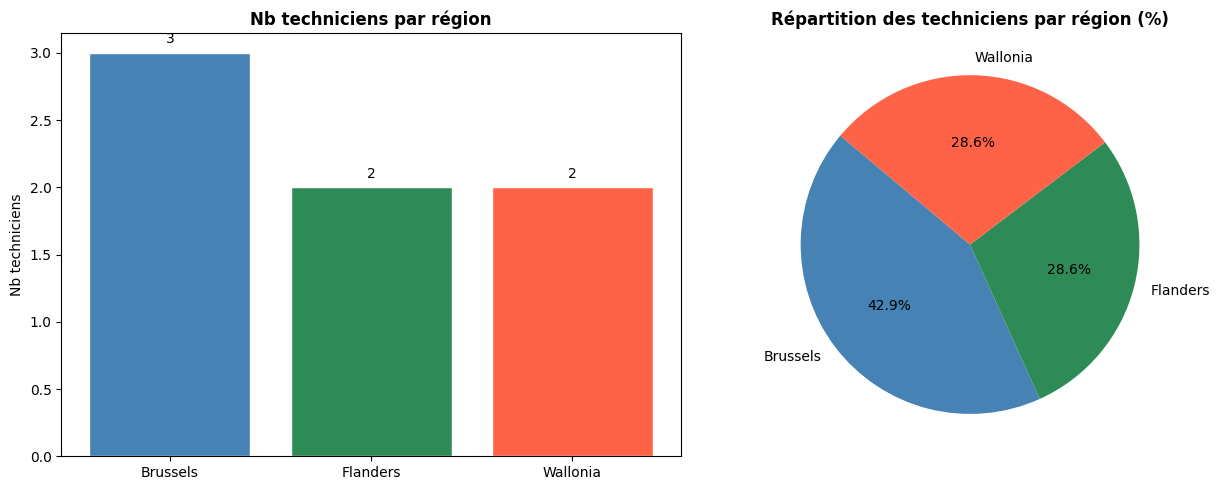

In [57]:
tech_region = tech['region'].value_counts().reset_index()
tech_region.columns = ['region', 'nb_techniciens']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(tech_region['region'], tech_region['nb_techniciens'],
                   color=[colors_region.get(r, 'grey') for r in tech_region['region']],
                   edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Nb techniciens par région', fontweight='bold')
axes[0].set_ylabel('Nb techniciens')

axes[1].pie(tech_region['nb_techniciens'],
            labels=tech_region['region'],
            autopct='%1.1f%%',
            colors=[colors_region.get(r, 'grey') for r in tech_region['region']],
            startangle=140)
axes[1].set_title('Répartition des techniciens par région (%)', fontweight='bold')

plt.tight_layout()
plt.show()

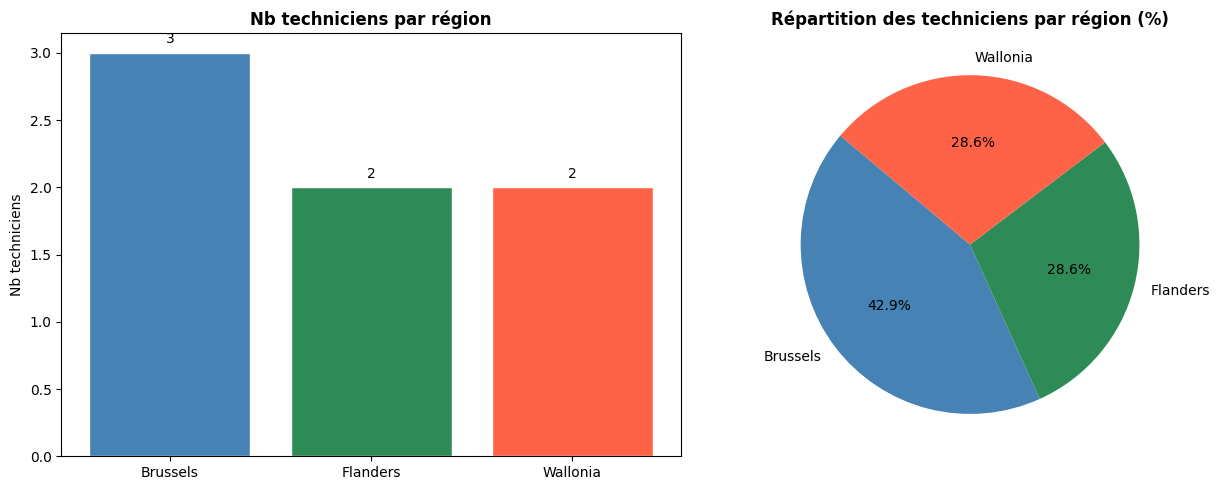

In [59]:
tech_region = tech['region'].value_counts().reset_index()
tech_region.columns = ['region', 'nb_techniciens']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(tech_region['region'], tech_region['nb_techniciens'],
                   color=[colors_region.get(r, 'grey') for r in tech_region['region']],
                   edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
axes[0].set_title('Nb techniciens par région', fontweight='bold')
axes[0].set_ylabel('Nb techniciens')

axes[1].pie(tech_region['nb_techniciens'],
            labels=tech_region['region'],
            autopct='%1.1f%%',
            colors=[colors_region.get(r, 'grey') for r in tech_region['region']],
            startangle=140)
axes[1].set_title('Répartition des techniciens par région (%)', fontweight='bold')

plt.tight_layout()
plt.show()